In [1]:
import pandas as pd
from matplotlib import pyplot as plt
from google.colab import files
import seaborn as sns

In [2]:
upload = files.upload()

Saving customer_churn_dataset-training-master.csv to customer_churn_dataset-training-master.csv


In [3]:
df = pd.read_csv('customer_churn_dataset-training-master.csv')

In [4]:
df.shape

(7043, 21)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [6]:
df.describe([0.01,0.05,0.95,0.99]).T

,count,mean,std,min,1%,5%,50%,95%,99%,max
SeniorCitizen,7043.0,0.162147,0.368612,0.00,0.0,0.00,0.00,1.0,1.000,1.00
tenure,7043.0,32.371149,24.559481,0.00,1.0,1.00,29.00,72.0,72.000,72.00
MonthlyCharges,7043.0,64.761692,30.090047,18.25,19.2,19.65,70.35,107.4,114.729,118.75


In [7]:
df.loc[:,['tenure', 'MonthlyCharges', 'TotalCharges']]

,tenure,MonthlyCharges,TotalCharges
0,1,29.85,29.85
1,34,56.95,1889.5
2,2,53.85,108.15
3,45,42.30,1840.75
4,2,70.70,151.65
...,...,...,...
7038,24,84.80,1990.5
7039,72,103.20,7362.9
7040,11,29.60,346.45
7041,4,74.40,306.6


# *TotalCharges variable datatype error*


In the df.info(), the variable 'TotalCharges' is of datatype object with a few values as ' ' that equate to zero. So, correcting this and converting the variable to type float.


In [8]:
df[(df['TotalCharges'] == ' ')]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,,No


In [9]:
df['TotalCharges'] = df['TotalCharges'].replace([' '], '0')

In [10]:
df['TotalCharges'] = df['TotalCharges'].astype(float)

In [11]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
SeniorCitizen,7043.0,0.162147,0.368612,0.00,0.00,0.00,0.00,1.00
tenure,7043.0,32.371149,24.559481,0.00,9.00,29.00,55.00,72.00
MonthlyCharges,7043.0,64.761692,30.090047,18.25,35.50,70.35,89.85,118.75
TotalCharges,7043.0,2279.734304,2266.794470,0.00,398.55,1394.55,3786.60,8684.80


# Scaling Numeric features: TotalCharges, tenure and MonthlyCharges

Compared both MinMaxScaler and StandardScaler. The tenure variable wasn't scaled as per the original distribution, so opted StandardScaler in all the three numeric variables.

In [12]:
#Scaling

#MinMaxScaling on TotalCharges
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
df['TotalCharges_mmscaled'] = scaler.fit_transform(df[['TotalCharges']])


In [13]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df['TotalCharges_sscaled'] = scaler.fit_transform(df[['TotalCharges']])

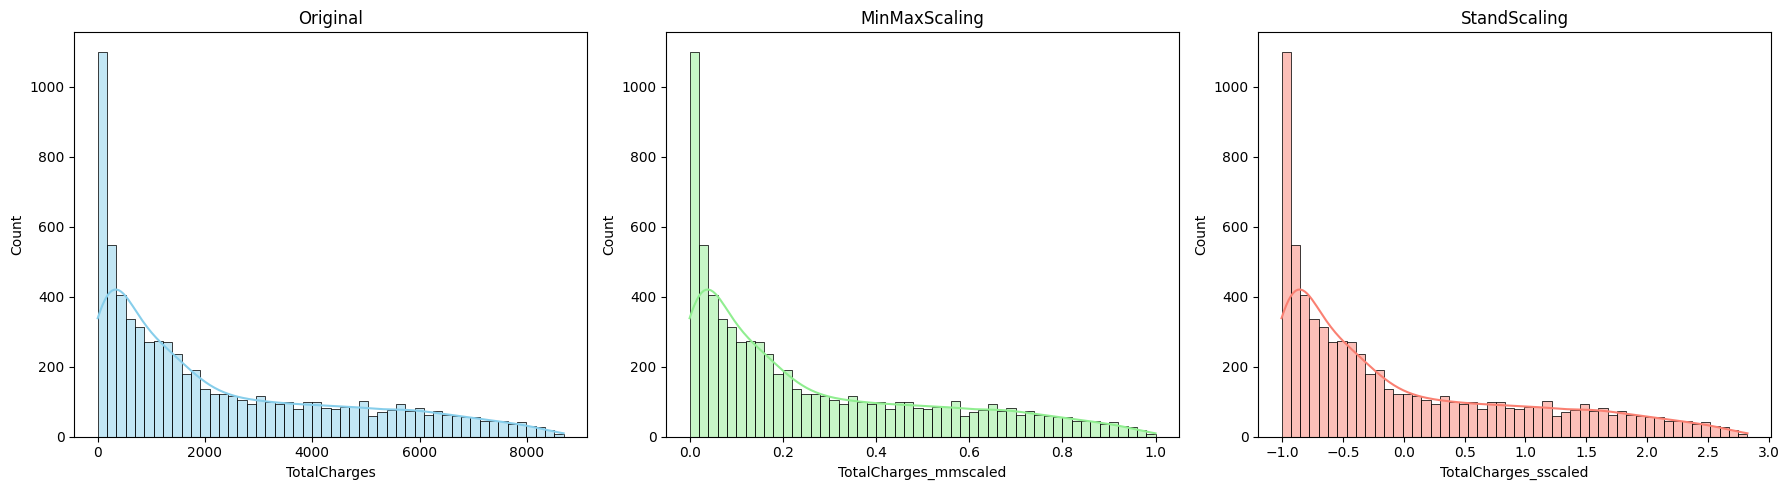

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))  # 1 row, 3 columns

# Plot each histogram
sns.histplot(df['TotalCharges'], ax=axes[0], bins=50, color='skyblue', kde = True)
axes[0].set_title('Original')


sns.histplot(df['TotalCharges_mmscaled'], ax=axes[1], bins=50, color='lightgreen', kde = True)
axes[1].set_title('MinMaxScaling')


sns.histplot(df['TotalCharges_sscaled'], ax=axes[2], bins=50, color='salmon',kde = True)
axes[2].set_title('StandScaling')


# Adjust layout
plt.tight_layout()
plt.show()

In [15]:
#Opting the Standard to match the tenure scaling values.
df.drop('TotalCharges_mmscaled', axis = 1, inplace = True)

In [16]:
df.rename({'TotalCharges_sscaled' : 'TotalCharges_scaled'}, inplace = True, axis = 1)

In [17]:
#Scaling tenure
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
df['tenure_mmscaled'] = scaler.fit_transform(df[['TotalCharges']])

In [18]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df['tenure_sscaled'] = scaler.fit_transform(df[['tenure']])

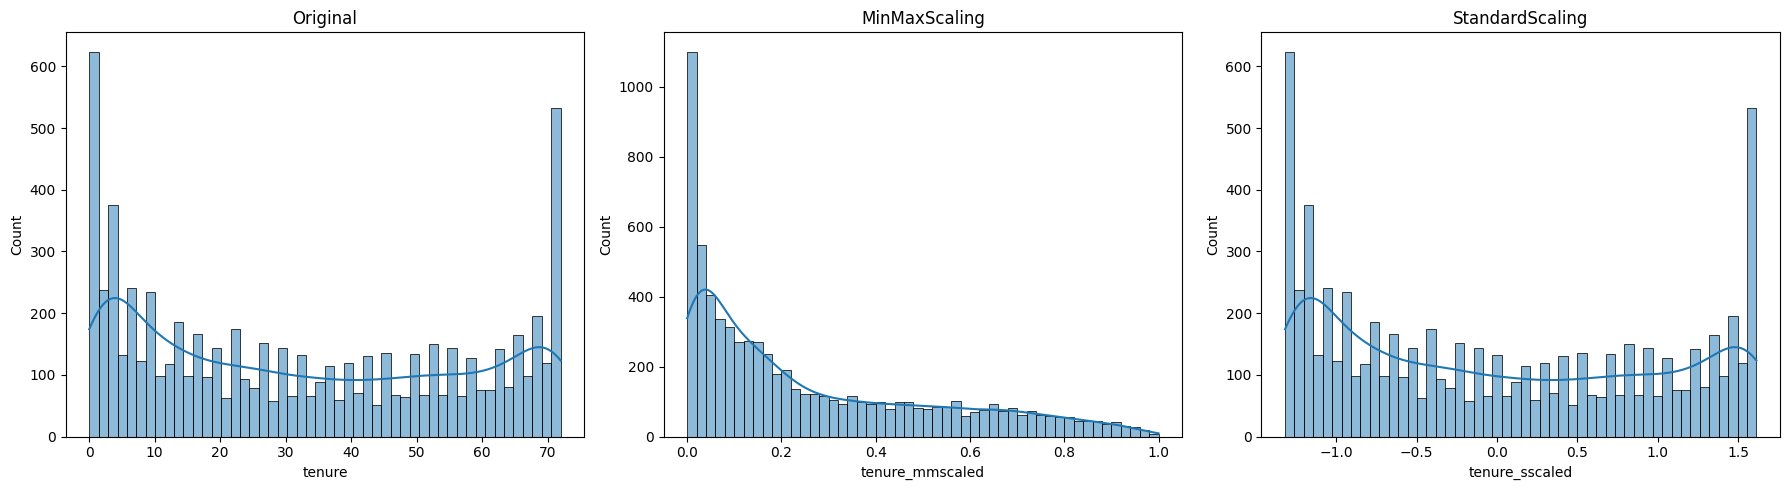

In [19]:
fig, axes = plt.subplots(1,3,figsize = (18,5))


sns.histplot(data = df, x = 'tenure', kde = True,bins = 50 , ax = axes[0])
axes[0].set_title('Original')

sns.histplot(data = df, kde = True, x = 'tenure_mmscaled', bins = 50, ax = axes[1])
axes[1].set_title('MinMaxScaling')

sns.histplot(data = df, x = 'tenure_sscaled', bins = 50, kde = True, ax = axes[2])
axes[2].set_title('StandardScaling')

plt.tight_layout()
plt.show()



In [20]:

#Opting Standard Scaler as the distribution is similar with original.
df.drop('tenure_mmscaled', axis = 1, inplace = True)
df.rename({'tenure_sscaled': 'tenure_scaled'}, inplace = True, axis = 1)

In [21]:
#Scaling MonthlyCharges

from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
df['MonthlyCharges_mmscaled'] = scaler.fit_transform(df[['MonthlyCharges']])

In [22]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df['MonthlyCharges_sscaled'] = scaler.fit_transform(df[['MonthlyCharges']])

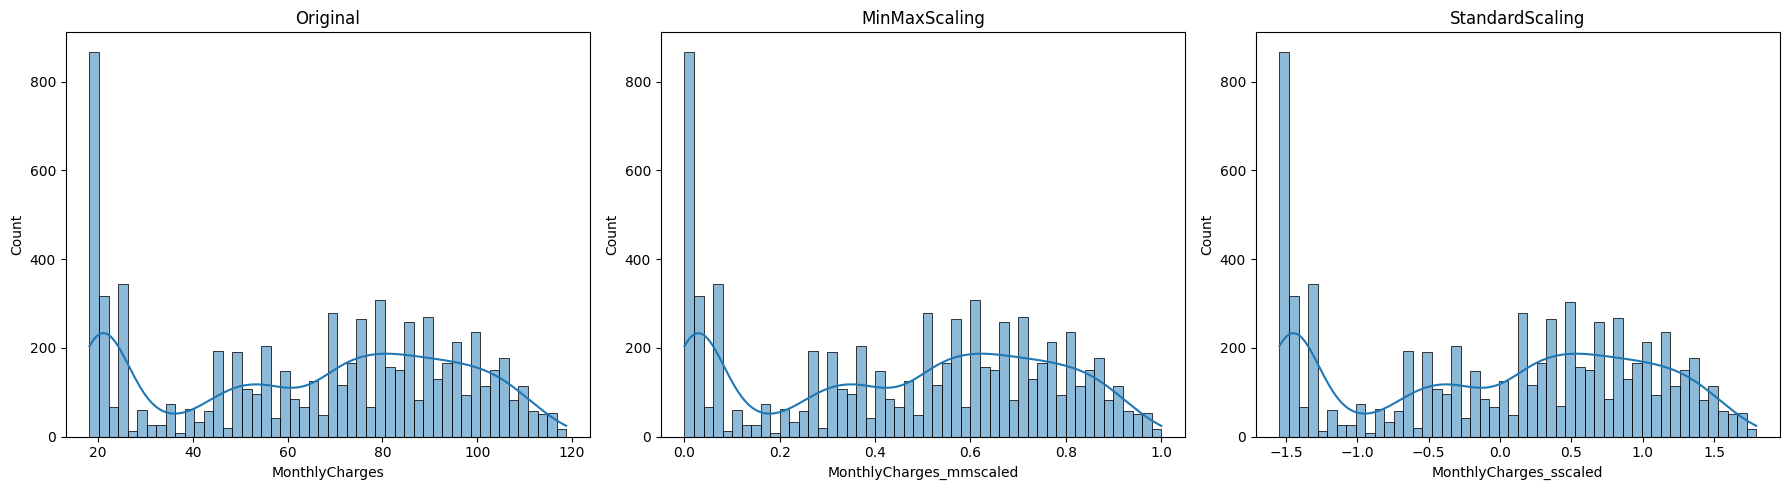

In [23]:
fig, axes = plt.subplots(1,3,figsize = (18,5))


sns.histplot(data = df, x = 'MonthlyCharges', kde = True,bins = 50 , ax = axes[0])
axes[0].set_title('Original')

sns.histplot(data = df, kde = True, x = 'MonthlyCharges_mmscaled', bins = 50, ax = axes[1])
axes[1].set_title('MinMaxScaling')

sns.histplot(data = df, x = 'MonthlyCharges_sscaled', bins = 50, kde = True, ax = axes[2])
axes[2].set_title('StandardScaling')

plt.tight_layout()
plt.show()



In [24]:
#Opting Standard Scaler to match the tenure column values.

df.drop('MonthlyCharges_mmscaled' , axis = 1, inplace = True)
df.rename({'MonthlyCharges_sscaled': 'MonthlyCharges_scaled'}, inplace = True, axis = 1)

In [25]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,TotalCharges_scaled,tenure_scaled,MonthlyCharges_scaled
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,-0.992611,-1.277445,-1.160323
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,No,One year,No,Mailed check,56.95,1889.50,No,-0.172165,0.066327,-0.259629
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,-0.958066,-1.236724,-0.362660
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,-0.193672,0.514251,-0.746535
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,-0.938874,-1.236724,0.197365


# Encoding Categorical Variables

Encoding 2 variables Churn and PaymentMethod which have 2 and 4 unique values respectively.

*One hot encoding is useful when we have ideally 2 unique values for a variable. So, I used it for the Churn variable.

*Ordinal encoding can be used for variables that have a few (3-6) unique values. Hence, I used this for encoding PaymentMethod.

In [26]:
#Categorical variables
for col in df.columns[:-3]: #Opting the last 3 scaled columns as it gives error (They are not 1 dimensional)
  if df[col].value_counts().size < 10 :
    print(df[col].value_counts(), '\n')

gender
Male      3555
Female    3488
Name: count, dtype: int64 

SeniorCitizen
0    5901
1    1142
Name: count, dtype: int64 

Partner
No     3641
Yes    3402
Name: count, dtype: int64 

Dependents
No     4933
Yes    2110
Name: count, dtype: int64 

PhoneService
Yes    6361
No      682
Name: count, dtype: int64 

MultipleLines
No                  3390
Yes                 2971
No phone service     682
Name: count, dtype: int64 

InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64 

OnlineSecurity
No                     3498
Yes                    2019
No internet service    1526
Name: count, dtype: int64 

OnlineBackup
No                     3088
Yes                    2429
No internet service    1526
Name: count, dtype: int64 

DeviceProtection
No                     3095
Yes                    2422
No internet service    1526
Name: count, dtype: int64 

TechSupport
No                     3473
Yes                    2044
No internet ser

In [27]:
#As Churn has only 2 distinct values, we can do one-hot encoding:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(sparse_output = False)
df[['Churn_No', 'Churn_Yes'] ] = pd.DataFrame(encoder.fit_transform(df[['Churn']]) )
df.drop('Churn_No', inplace = True, axis = 1)
df.rename(columns = {'Churn_Yes':'Churn_encoded'}, inplace = True)
df[['Churn', 'Churn_encoded']].head()

,Churn,Churn_encoded
0,No,0.0
1,No,0.0
2,Yes,1.0
3,No,0.0
4,Yes,1.0


In [28]:
#Encoding PaymentMethod with Ordinal Encoding, as there are 4 unique values with each of them taking 20% of the distribution.
from sklearn.preprocessing import OrdinalEncoder

encoder = OrdinalEncoder(categories = [['Electronic check', 'Mailed check', 'Bank transfer (automatic)', 'Credit card (automatic)']])
df['PaymentMethod_encoded'] = encoder.fit_transform(df[['PaymentMethod']])

In [29]:
df[['PaymentMethod', 'PaymentMethod_encoded']].head()

,PaymentMethod,PaymentMethod_encoded
0,Electronic check,0.0
1,Mailed check,1.0
2,Mailed check,1.0
3,Bank transfer (automatic),2.0
4,Electronic check,0.0


In [39]:
df.drop(['PaymentMethod', 'Churn'], inplace=True, axis = 1)

*Encoding all other categorical variables as the model.fit() will not work without it.*

Reference: ChatGPT : https://chatgpt.com/share/6868d4ea-81fc-800e-8113-0644478739de

In [42]:
#Encoding all categorical variables.
for col in df.columns[df.dtypes == 'object']:
    encoder = OrdinalEncoder()
    df[col] = encoder.fit_transform(df[[col]])


In [45]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 24 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   customerID             7043 non-null   float64
 1   gender                 7043 non-null   float64
 2   SeniorCitizen          7043 non-null   int64  
 3   Partner                7043 non-null   float64
 4   Dependents             7043 non-null   float64
 5   tenure                 7043 non-null   int64  
 6   PhoneService           7043 non-null   float64
 7   MultipleLines          7043 non-null   float64
 8   InternetService        7043 non-null   float64
 9   OnlineSecurity         7043 non-null   float64
 10  OnlineBackup           7043 non-null   float64
 11  DeviceProtection       7043 non-null   float64
 12  TechSupport            7043 non-null   float64
 13  StreamingTV            7043 non-null   float64
 14  StreamingMovies        7043 non-null   float64
 15  Cont

# Feature Engineering

Creating new variables that adds extra value above the existing variables is called Feature Engineering. I have created 3 new variables: tenure_years, long_contract and StreamingServices.

Code source: ChatGPT.


In [46]:
#It is gets more intuitive to see the tenure in years.
df['tenure_years'] = df['tenure']/12

In [47]:
#If a customer is with the company from an year, we have a long contract with him. We can create a new feature that flags commitment of customers
df['long_contract'] = df['tenure_years'] >= 1
df['long_contract'] = df['long_contract'].astype(int)

In [48]:
#Calculating the number of streaming services a customer has taken.
df[['StreamingTV', 'StreamingMovies']] = df[['StreamingTV', 'StreamingMovies']].replace({'No internet service' : 'No'})

In [49]:
df['StreamingTV'] = df['StreamingTV'].replace({'No' : 0, 'Yes' : 1})
df['StreamingMovies'] = df['StreamingMovies'].replace({'No' : 0, 'Yes' : 1})

In [50]:
df['StreamingServices'] = df['StreamingMovies'] + df['StreamingTV']

In [51]:
df.loc[:,['StreamingMovies','StreamingTV', 'StreamingServices']]

,StreamingMovies,StreamingTV,StreamingServices
0,0.0,0.0,0.0
1,0.0,0.0,0.0
2,0.0,0.0,0.0
3,0.0,0.0,0.0
4,0.0,0.0,0.0
...,...,...,...
7038,2.0,2.0,4.0
7039,2.0,2.0,4.0
7040,0.0,0.0,0.0
7041,0.0,0.0,0.0


# Final Validation

Checking if everything is working fine with the dataset and can be exported.


In [52]:
df.isna().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [53]:
df.drop_duplicates(inplace = True)

In [54]:
df.shape

(7043, 27)

In [55]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
customerID,7043.0,3.521000e+03,2033.283305,0.000000,1760.500000,3521.000000,5281.500000,7042.000000
gender,7043.0,5.047565e-01,0.500013,0.000000,0.000000,1.000000,1.000000,1.000000
SeniorCitizen,7043.0,1.621468e-01,0.368612,0.000000,0.000000,0.000000,0.000000,1.000000
Partner,7043.0,4.830328e-01,0.499748,0.000000,0.000000,0.000000,1.000000,1.000000
Dependents,7043.0,2.995882e-01,0.458110,0.000000,0.000000,0.000000,1.000000,1.000000
tenure,7043.0,3.237115e+01,24.559481,0.000000,9.000000,29.000000,55.000000,72.000000
PhoneService,7043.0,9.031663e-01,0.295752,0.000000,1.000000,1.000000,1.000000,1.000000
MultipleLines,7043.0,9.405083e-01,0.948554,0.000000,0.000000,1.000000,2.000000,2.000000
InternetService,7043.0,8.729235e-01,0.737796,0.000000,0.000000,1.000000,1.000000,2.000000
OnlineSecurity,7043.0,7.900043e-01,0.859848,0.000000,0.000000,1.000000,2.000000,2.000000


In [56]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,MonthlyCharges,TotalCharges,TotalCharges_scaled,tenure_scaled,MonthlyCharges_scaled,Churn_encoded,PaymentMethod_encoded,tenure_years,long_contract,StreamingServices
0,5375.0,0.0,0,1.0,0.0,1,0.0,1.0,0.0,0.0,...,29.85,29.85,-0.992611,-1.277445,-1.160323,0.0,0.0,0.083333,0,0.0
1,3962.0,1.0,0,0.0,0.0,34,1.0,0.0,0.0,2.0,...,56.95,1889.50,-0.172165,0.066327,-0.259629,0.0,1.0,2.833333,1,0.0
2,2564.0,1.0,0,0.0,0.0,2,1.0,0.0,0.0,2.0,...,53.85,108.15,-0.958066,-1.236724,-0.362660,1.0,1.0,0.166667,0,0.0
3,5535.0,1.0,0,0.0,0.0,45,0.0,1.0,0.0,2.0,...,42.30,1840.75,-0.193672,0.514251,-0.746535,0.0,2.0,3.750000,1,0.0
4,6511.0,0.0,0,0.0,0.0,2,1.0,0.0,1.0,0.0,...,70.70,151.65,-0.938874,-1.236724,0.197365,1.0,0.0,0.166667,0,0.0


In [57]:
df.to_csv('customer_churn_gold.csv')

#DOCUMENTATION

**Goal of the Notebook**

To transform the current Silver layer dataset into a Gold Layer Dataset by scaling, encoding and featuring new variables such that the dataset is ready for model.fit()




**Transformations applied**



1.   Scaled 3 numeric variables using MinMaxScaler and StandardScaler and compared the distribution to choose the best scaler.
2.   Encoded 2 categorical variables using one-hot encoder and ordinal encoder.
3. Created 3 new features using the existing features to utilize the given data to its most.



**Challenges faced and clean up needed**

Identified the datatype of TotalCharges to be an object which should've been float. So, found out the missing values in the variable and later converted the datatype into float.


**Next steps**

Do some dimensionality reduction if needed.

Split the data into train/test for model.fit().

